# 多策略回测：Python API

把 MOM / STR / WSTR 三路 alpha 一次性喂进工具包横向比较。与
[quickstart_multi_signal.ipynb](quickstart_multi_signal.ipynb) 跑的是同一件事，
区别在于入口：那篇写四份 JSON 配置，这篇全程用 `alp.backtest(...)`。

两条路径共用同一套校验与计算，结果逐值一致——第 9 节会当场验证这一点。

新版入口带来三处变化：

- **因子表直接传 DataFrame**，不必先 `to_feather()` 落盘
- **列名与调仓口径自动推导**，`column_map`、`rebalance_freq`、`weights` 通常不用写
- **结果是对象不是文件**，`summary()` / `plot()` / `returns` 随手取用


In [1]:
# plot() 返回的 Figure 脱离 pyplot 全局状态直接构造，Jupyter 需要 inline 后端才会渲染
%matplotlib inline

import alpholio as alp

alp.__version__

'0.4.0'

## 1 造三路 alpha

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.feather as feather

# 价格面板位置。设环境变量 ALPHOLIO_PRICES 指向本机实际文件即可，无需改动本 notebook。
PRICES = os.environ.get(
    "ALPHOLIO_PRICES", "/path/to/stock_rag_cache/processed/processed_stock_data.feather"
)

HORIZON = 5          # 前视收益跨多少个交易日
FIRST = "2021-01-04"

feather.read_table(PRICES, memory_map=True).schema.names[:16]

['date',
 'id',
 'siccd',
 'close',
 'cap',
 'ret',
 'vol',
 'low',
 'high',
 'open',
 'shares',
 'market_cap',
 'label',
 'log_ret',
 'cum_log_ret',
 'ewma_vol']

In [3]:
%%time
# 一次读齐：价格面板给回测用，cum_log_ret 用来算前视收益
panel = feather.read_table(
    PRICES, columns=["date", "id", "close", "cap", "cum_log_ret"], memory_map=True
).to_pandas().sort_values(["id", "date"], kind="stable", ignore_index=True)

print(f"{len(panel):,} 行 × {panel.shape[1]} 列，{panel.memory_usage(deep=True).sum()/1e9:.2f} GB")
panel.head(3)

49,799,062 行 × 5 列，1.99 GB
CPU times: user 5.19 s, sys: 3.48 s, total: 8.67 s
Wall time: 6.38 s


,date,id,close,cap,cum_log_ret
0,1992-01-02,10001,14.5,15587.5,0.0
1,1992-01-03,10001,14.5,15587.5,0.0
2,1992-01-06,10001,14.5,15587.5,0.0


In [4]:
%%time
g = panel.groupby("id", sort=False)
close = panel["close"]

alphas = {
    "MOM":  g["close"].shift(21) / g["close"].shift(252) - 1.0,
    "STR":  -(close / g["close"].shift(21) - 1.0),
    "WSTR": -(close / g["close"].shift(5) - 1.0),
}
fwd_ret = np.exp(g["cum_log_ret"].shift(-HORIZON) - panel["cum_log_ret"]) - 1.0

days = pd.DatetimeIndex(np.unique(panel["date"].to_numpy()))
anchors = set(days[days >= FIRST][::HORIZON])     # 调仓日与测量期同步长

base = panel[["date", "id"]].assign(fwd_ret=fwd_ret.to_numpy())
signals = {
    name: (
        base.assign(alpha=series.to_numpy())
        .query("date in @anchors")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["alpha"])
        .sort_values(["date", "id"], kind="stable", ignore_index=True)
    )
    for name, series in alphas.items()
}

# 价格面板留下回测需要的四列，close 与 cap 分别供前视收益和市值加权使用
prices = panel[["date", "id", "close", "cap"]]
del alphas, fwd_ret, g, close, base

pd.DataFrame({
    name: {
        "行数": len(df),
        "调仓日": df["date"].nunique(),
        "股票数": df["id"].nunique(),
        "alpha 均值": round(df["alpha"].mean(), 4),
        "alpha 标准差": round(df["alpha"].std(), 4),
    }
    for name, df in signals.items()
}).T

CPU times: user 8.41 s, sys: 4.42 s, total: 12.8 s
Wall time: 11.1 s


,行数,调仓日,股票数,alpha 均值,alpha 标准差
MOM,1211662.0,251.0,6786.0,0.3714,4.6757
STR,1320237.0,251.0,7385.0,-0.0640,2.4065
WSTR,1328053.0,251.0,7449.0,-0.0184,1.2939


In [5]:
# 信号表长这样：一行一个 (调仓日, 股票)，alpha 是打分，fwd_ret 是实现收益
signals["MOM"].head(3)

,date,id,fwd_ret,alpha
0,2021-01-04,10026,0.005321,-0.231237
1,2021-01-04,10028,0.120623,2.021429
2,2021-01-04,10032,0.081269,-0.020332


## 2 跑

三路信号用映射给出，键即信号名。因子表与价格表都是内存里的 DataFrame，不经过磁盘。

In [6]:
%%time
bt = alp.backtest(
    signals=signals,          # {名称: DataFrame}
    prices=prices,            # DataFrame
    horizon=HORIZON,
    first_rebalance=FIRST,
    n_buckets=10,
    min_names=20,
    metrics=["ann_ret", "ann_vol", "sharpe", "max_drawdown", "total_equity", "hit_rate"],
)
bt

CPU times: user 18.8 s, sys: 4.43 s, total: 23.2 s
Wall time: 23.2 s


BacktestResult(signals=['MOM', 'STR', 'WSTR'], horizon=5, n_buckets=10, weights=['EW', 'VW'], periods=250)
signal_model bucket weight  n_periods  ann_ret  ann_vol  sharpe  max_drawdown  total_equity  hit_rate  turnover  ic_mean
         MOM    H-L     EW        250   0.0923   0.2153  0.4288       -0.4202        1.4060     0.572    0.2648   0.0291
         MOM    H-L     VW        250   0.1714   0.3024  0.5670       -0.3767        1.8676     0.528    0.2648   0.0291
         STR    H-L     EW        250   0.1383   0.1874  0.7377       -0.2120        1.8208     0.512    0.5768   0.0023
         STR    H-L     VW        250  -0.1437   0.2998 -0.4792       -0.6866        0.3918     0.488    0.5768   0.0023
        WSTR    H-L     EW        250   0.3156   0.1758  1.7950       -0.1564        4.4170     0.588    0.7891   0.0240
        WSTR    H-L     VW        250   0.0270   0.2973  0.0907       -0.4773        0.9207     0.492    0.7891   0.0240

## 3 自动推导了什么

三处默认值按数据定，省掉了手工保持一致的负担。

In [7]:
pd.DataFrame([
    {
        "项": "weights",
        "取值": bt.weights,
        "依据": "价格面板有 cap 列 → 加上市值加权；没有则只做等权",
    },
    {
        "项": "rebalance_freq",
        "取值": bt.config.input.calendar.rebalance_freq,
        "依据": "缺省等于 horizon，使相邻持有窗口首尾相接",
    },
    {
        "项": "forward_return.source",
        "取值": bt.config.engine.forward_return.source,
        "依据": "信号自带 fwd_ret → 用该列；没有才由 close 推算",
    },
    {
        "项": "column_map",
        "取值": "自动识别",
        "依据": "列名已是 date / id / alpha / close / cap，无需声明映射",
    },
]).set_index("项")

,取值,依据
项,,
weights,"[EW, VW]",价格面板有 cap 列 → 加上市值加权；没有则只做等权
rebalance_freq,5,缺省等于 horizon，使相邻持有窗口首尾相接
forward_return.source,signals,信号自带 fwd_ret → 用该列；没有才由 close 推算
column_map,自动识别,列名已是 date / id / alpha / close / cap，无需声明映射


两项值得单说。

**`rebalance_freq`** 与 `horizon` 不等时，相邻两期的持有窗口会重叠或留下空仓缺口，逐期累乘出的
净值、`total_equity` 与 `max_drawdown` 因此失真。写 JSON 时这两个数字分处 `input.json` 与
`engine.json`，靠人工保持一致；缺省取同值把正确口径变成了默认。

**`forward_return.source`** 取 `"signals"`，因为上面算的三路信号都带了 `fwd_ret` 列。自带列优先于
价格面板的 `close`：`fwd_ret` 是专门算过一遍实现收益的结果（这里由 `cum_log_ret` 得到，含分红调整），
而 `close` 往往只是价格面板顺带提供的——它本来就要承担交易日历与市值关联两项职责。两种口径在
含分红的数据上能差出数量级。

自动缺省不掩盖有意为之的差异——显式给出不同取值仍会照常告警，见第 7 节。

## 4 指标

In [8]:
# 三路策略的多空腿横向对比 —— 多信号最直接的用处
bt.summary(bucket="H-L").round(4)

,signal_model,bucket,weight,n_periods,ann_ret,ann_vol,sharpe,max_drawdown,total_equity,hit_rate,turnover,ic_mean
0,MOM,H-L,EW,250,0.0923,0.2153,0.4288,-0.4202,1.4060,0.572,0.2648,0.0291
1,MOM,H-L,VW,250,0.1714,0.3024,0.5670,-0.3767,1.8676,0.528,0.2648,0.0291
2,STR,H-L,EW,250,0.1383,0.1874,0.7377,-0.2120,1.8208,0.512,0.5768,0.0023
3,STR,H-L,VW,250,-0.1437,0.2998,-0.4792,-0.6866,0.3918,0.488,0.5768,0.0023
4,WSTR,H-L,EW,250,0.3156,0.1758,1.7950,-0.1564,4.4170,0.588,0.7891,0.0240
5,WSTR,H-L,VW,250,0.0270,0.2973,0.0907,-0.4773,0.9207,0.492,0.7891,0.0240


In [9]:
# 分位单调性：等权口径下每路策略的十分位年化收益
(
    bt.summary(weight="EW")
    .query("bucket != 'H-L'")
    .pivot(index="bucket", columns="signal_model", values="ann_ret")
    .reindex([str(i) for i in range(10)])
    .round(4)
)

signal_model,MOM,STR,WSTR
bucket,,,
0,-0.0772,-0.0990,-0.2011
1,0.0337,0.0451,-0.0053
2,0.0809,0.0676,0.0404
3,0.0938,0.0714,0.0282
4,0.0903,0.0767,0.0778
5,0.1006,0.0936,0.1364
6,0.0990,0.1173,0.1245
7,0.1164,0.0921,0.1264
8,0.1145,0.0479,0.1157


In [10]:
# IC 与换手逐信号独立计算
pd.DataFrame({
    "IC 均值": bt.ic.groupby("signal_model")["ic"].mean(),
    "IC 标准差": bt.ic.groupby("signal_model")["ic"].std(),
    "换手均值": bt.turnover.query("bucket == 'H-L'").groupby("signal_model")["turnover"].mean(),
}).round(4)

,IC 均值,IC 标准差,换手均值
signal_model,,,
MOM,0.0291,0.1409,0.2648
STR,0.0023,0.1262,0.5768
WSTR,0.0240,0.1295,0.7891


In [11]:
# 中间产物原样保留，二次分析不用重跑
print("returns ", bt.returns.shape, list(bt.returns.columns))
print("curves  ", bt.curves.shape)
print("members ", bt.members.shape)
print("aligned ", bt.aligned.shape)
bt.returns.head(3)

returns  (16500, 6) ['date', 'signal_model', 'bucket', 'weight', 'ret', 'count']
curves   (16566, 7)
members  (3838332, 4)
aligned  (3838332, 6)


,date,signal_model,bucket,weight,ret,count
0,2021-01-04,MOM,0,EW,0.111624,445
1,2021-01-11,MOM,0,EW,0.062962,446
2,2021-01-19,MOM,0,EW,0.019532,446


## 5 图

`plot()` 按预设名出图，返回 matplotlib `Figure`，可以继续用原生 API 调整。

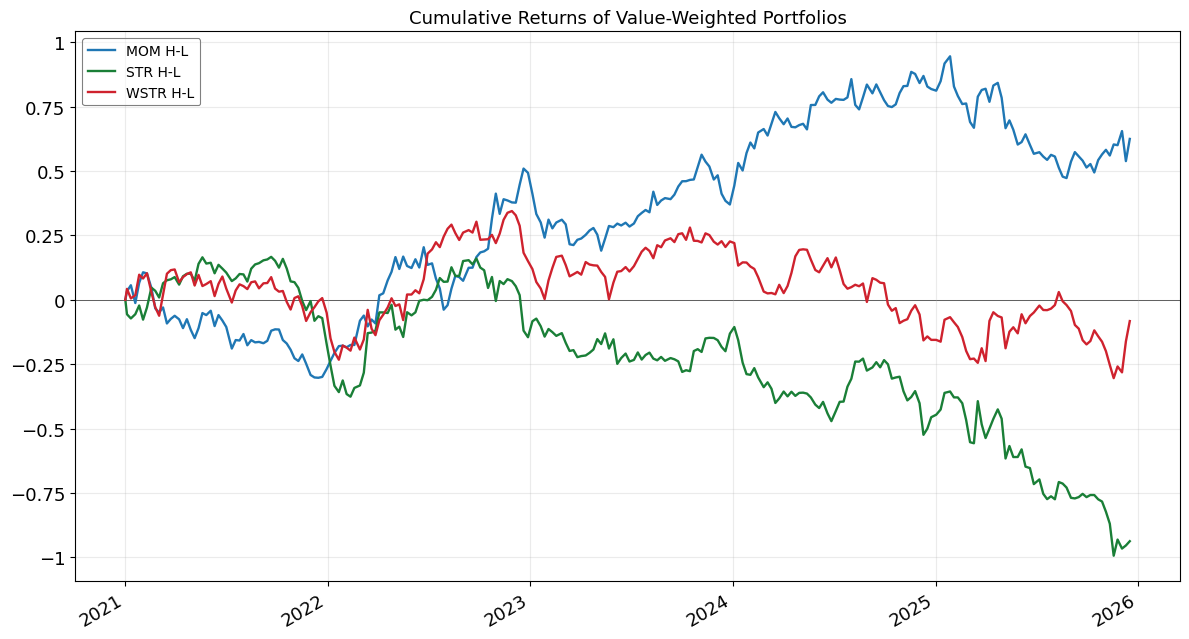

In [12]:
# 策略对比图：三路信号叠在一张上
bt.plot("long_short", weight="VW")

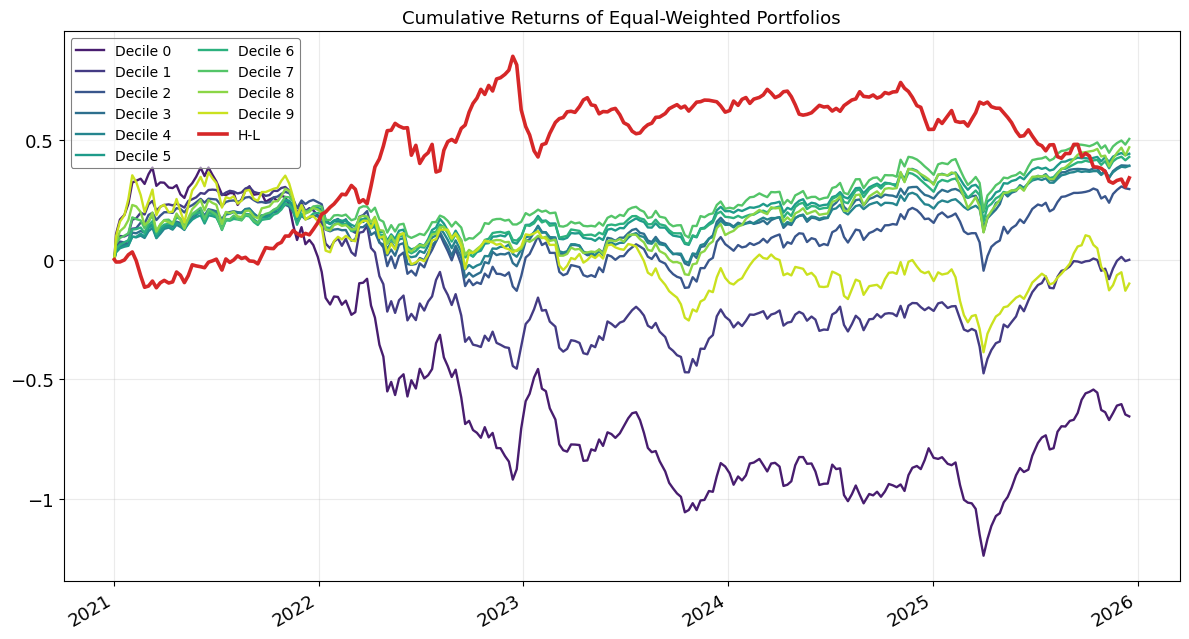

In [13]:
# 分位图：拆解单一策略的内部结构，多路信号时用 signal 指定看哪一路
bt.plot("deciles", weight="EW", signal="MOM")

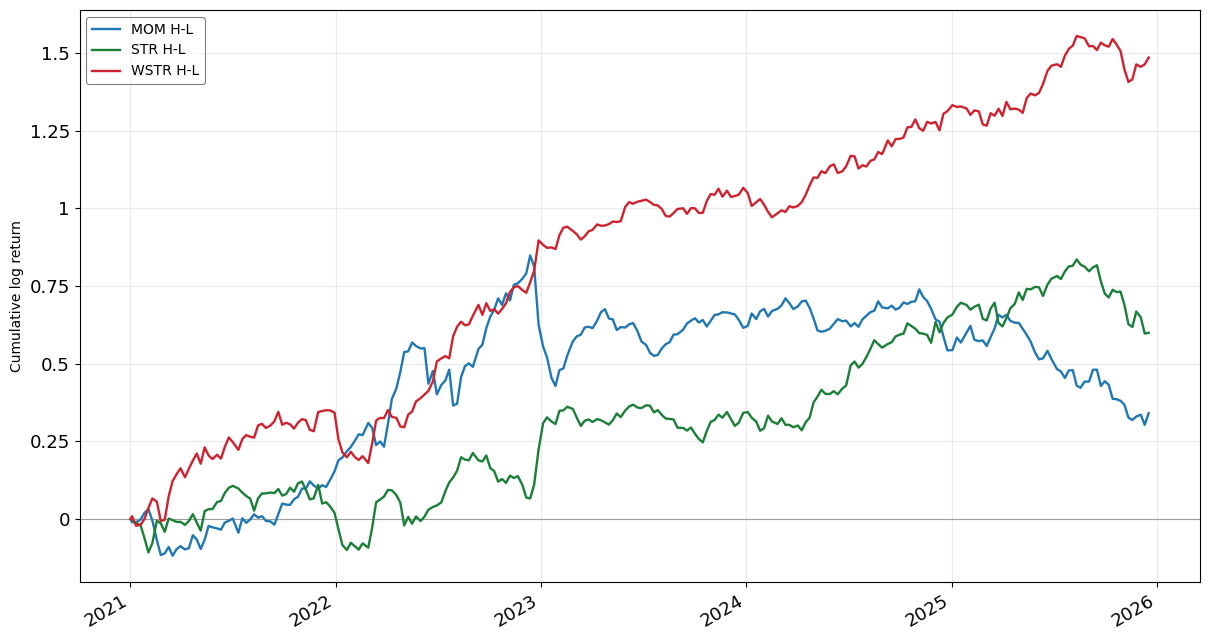

In [14]:
# 返回的是原生 Figure，出版前的微调照常做
fig = bt.plot("long_short", weight="EW", show_title=False)
ax = fig.axes[0]
ax.set_ylabel("Cumulative log return")
ax.axhline(0, color="#999999", linewidth=0.8, zorder=1)
fig

## 6 全局样式

样式字段有五十余个，改动频率远低于口径参数，因此集中在 `alp.settings` 而不是塞进函数签名。
改一次对之后每次渲染生效。

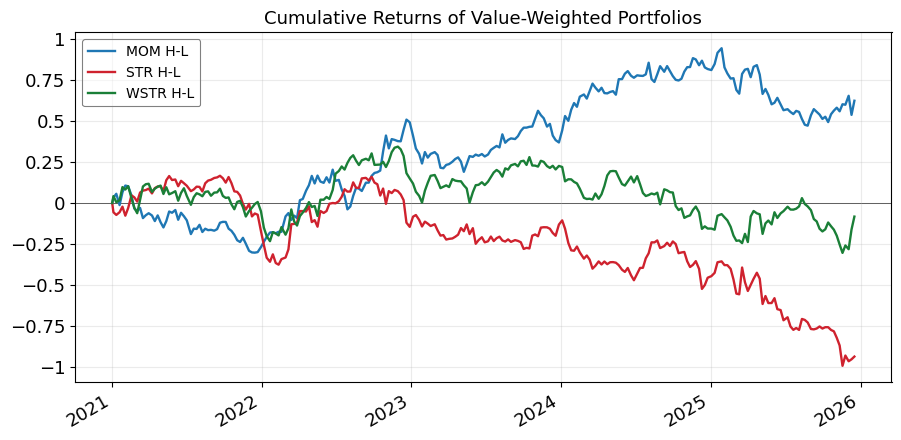

In [15]:
alp.settings.style.figsize = [9.0, 4.5]
alp.settings.style.gradient_colormap = "plasma"
alp.settings.style.palette = {"MOM": "#1f77b4", "STR": "#cf222e", "WSTR": "#1a7f37"}

bt.plot("long_short", weight="VW")

In [16]:
alp.settings.reset()        # 复原出厂默认
alp.settings

Settings(style=StyleSpec(...), output_dir=None)

## 7 `horizon` 与 `holding_days`

`horizon` 定义每期实现收益的测量期长度，是全包唯一的「一期有多长」。`holding_days` 只影响年化折算，
留空即继承 `horizon`。两者显式不等时告警但不中断——那意味着收益的测量期与年化时假定的持有期
不是同一件事。

In [17]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    alp.backtest(
        signals={"MOM": signals["MOM"]}, prices=prices,
        horizon=HORIZON, holding_days=21, first_rebalance=FIRST,
    )

for w in caught:
    print(f"{w.category.__name__}:")
    print(" ", str(w.message).replace("，", "，\n  "))

  engine.holding_days=21 与 engine.forward_return.horizon=5 不一致：每期实现收益按 5 期测量（基准同窗口口径），
  而年化因子按每年「年化基数/21」期折算（基数随 input.frequency：日度取 analyzer.trading_days_per_year，
  默认 252；月度取 12）。两者不等意味着组合收益的测量期与声称的持有期不是同一件事，
  年化收益/波动/夏普会相应偏移；确属有意为之可忽略本条。


## 8 扫参数

门面不遮挡下层。`bt.bundle` 是标准化后的输入，复用它扫参数就不必反复读那 5 千万行面板。

In [18]:
%%time
from alpholio import Analyzer, PortfolioEngine
from alpholio.config_schema import AnalyzerConfig, EngineConfig, ForwardReturnSpec

rows = []
for n in (5, 10, 20):
    cfg = EngineConfig(
        n_buckets=n, min_names=20, weights=["ew"],
        forward_return=ForwardReturnSpec(horizon=HORIZON, source="signals"),
    )
    summary = Analyzer(AnalyzerConfig()).run(PortfolioEngine(cfg).run(bt.bundle)).summary
    hl = summary.query("bucket == 'H-L' and weight == 'EW'")
    rows += [{"n_buckets": n, "signal": r["signal_model"], "sharpe": r["sharpe"]}
             for _, r in hl.iterrows()]

pd.DataFrame(rows).pivot(index="signal", columns="n_buckets", values="sharpe").round(4)

CPU times: user 30.9 s, sys: 3.38 s, total: 34.3 s
Wall time: 34.2 s


n_buckets,5,10,20
signal,,,
MOM,0.4840,0.4288,0.0739
STR,0.4511,0.7377,1.0752
WSTR,1.4681,1.7950,2.1055


## 9 落盘与归档

`save()` 出图出表；`to_config()` 把本次实验导成四份 JSON，供 `run_pipeline` 复现或随论文归档。

内存 DataFrame 写不进 JSON，因此导出时需给出 `data_dir`：表先落盘到该目录，再把路径写进配置。
复现包本就需要数据随行。

In [19]:
# 产物写入目录。设环境变量 ALPHOLIO_WORK 指向本机缓存根目录即可。
WORK = Path(os.environ.get("ALPHOLIO_WORK", "/path/to/portfolio_tool_cache")) / "api_quickstart"
OUT = WORK / "outputs"

for path in bt.save(OUT):
    print("wrote", path.name)

wrote long_short_ew.png
wrote long_short_vw.png
wrote deciles_mom_ew.png
wrote deciles_str_ew.png
wrote deciles_wstr_ew.png
wrote deciles_mom_vw.png
wrote deciles_str_vw.png
wrote deciles_wstr_vw.png
wrote metrics.csv
wrote turnover.csv
wrote ic.csv
wrote summary_metrics.csv
wrote curves.feather


In [20]:
paths = bt.to_config(WORK / "configs", data_dir=WORK / "data")
print("\n".join(str(p) for p in paths))

import json as _json
print()
print(_json.dumps(_json.loads((WORK / "configs" / "engine.json").read_text()), indent=2))

/mnt/df7c3e41-975f-4e19-950b-bf2143e9dd82/MingzhiYang/portfolio_tool_cache/api_quickstart/configs/input.json
/mnt/df7c3e41-975f-4e19-950b-bf2143e9dd82/MingzhiYang/portfolio_tool_cache/api_quickstart/configs/engine.json
/mnt/df7c3e41-975f-4e19-950b-bf2143e9dd82/MingzhiYang/portfolio_tool_cache/api_quickstart/configs/analyzer.json
/mnt/df7c3e41-975f-4e19-950b-bf2143e9dd82/MingzhiYang/portfolio_tool_cache/api_quickstart/configs/visualizer.json

{
  "n_buckets": 10,
  "min_names": 20,
  "holding_days": 5,
  "weights": [
    "ew",
    "vw"
  ],
  "weight_options": {},
  "include_references": false,
  "reference_lag": 1,
  "long_short": {
    "enabled": true,
    "label": "H-L",
    "reverse": false
  },
  "forward_return": {
    "horizon": 5,
    "source": "signals",
    "clip_lower": null
  }
}


### 两条路径算出同一个结果

导出的配置交给 `run_pipeline` 重跑，指标表应与门面的结果逐值一致。这是两条入口口径相同的直接证据。

In [21]:
%%time
replayed = alp.run_pipeline(WORK / "configs", render=False)

pd.testing.assert_frame_equal(
    bt.summary(), replayed.analysis.summary.reset_index(drop=True)
)
print("✓ 指标表逐值一致：", bt.summary().shape)

✓ 指标表逐值一致： (66, 12)
CPU times: user 21.4 s, sys: 5.89 s, total: 27.3 s
Wall time: 24.5 s


## 10 产物

In [22]:
print("图与表平铺在同一层，不分子目录：")
for p in sorted(OUT.iterdir()):
    print(f"  {p.name:36s} {p.stat().st_size/1024:8.1f} KB")

图与表平铺在同一层，不分子目录：
  curves.feather                          590.9 KB
  deciles_mom_ew.png                      381.9 KB
  deciles_mom_vw.png                      440.6 KB
  deciles_str_ew.png                      407.3 KB
  deciles_str_vw.png                      412.4 KB
  deciles_wstr_ew.png                     330.1 KB
  deciles_wstr_vw.png                     469.5 KB
  ic.csv                                   29.9 KB
  long_short_ew.png                       176.4 KB
  long_short_vw.png                       194.3 KB
  metrics.csv                               4.3 KB
  summary_metrics.csv                      10.2 KB
  turnover.csv                            291.9 KB


## 什么时候该回到配置目录

`backtest()` 覆盖交互式分析。以下场景配置目录仍然更合适：

| 场景 | 原因 |
|---|---|
| 服务器批量执行 | `alpholio run --config-dir` 不需要写 Python |
| 随论文归档 | 一份能进版本库、能 diff 的配置便于复核 |
| 非常规图表 | `charts[]` 的十七个字段比两个预设名更细 |

两者可以来回切换：notebook 里调好参数 `to_config()` 导出，配置目录里的实验
`run_pipeline()` 读回。完整参数表见
[Python API 参考](https://mzyang-code.github.io/alpholio/reference/api/)。